In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [4]:
df=pd.read_csv(r"C:\Users\k9481\OneDrive\Documents\ml databases\WineQT.csv")

In [5]:
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Columns You'll Work With

Column                     Meaning
fixed acidity              Amount of fixed acids
volatile acidity           Amount of volatile acids
citric acid                Citric acid content
residual sugar             Remaining sugar after fermentation
chlorides                  Salt content
free sulfur dioxideFree    SO2
total sulfur dioxideTotal  SO2density
Wine densitypH             Acidity level (0-14)
sulphates                  Preservative amount
alcohol                    Alcohol percentage
quality                    Target — Rating 0-10

-------------------------------------------------------------------------------
Convert Target to Binary
***This is the key learning — convert continuous to binary classification:

In [6]:
# Original quality is 0-10
print("Original quality distribution:")
print(df['quality'].value_counts().sort_index())


Original quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [7]:
# Convert to Good/Bad (binary)
# Quality >= 6 = Good wine, < 6 = Bad wine
df['quality_binary'] = (df['quality'] >= 6).astype(int)


In [8]:
print("\nBinary distribution:")
print(df['quality_binary'].value_counts())
# 0 = Bad wine, 1 = Good wine


Binary distribution:
quality_binary
1    621
0    522
Name: count, dtype: int64


In [9]:
# Drop original quality column
df.drop('quality', axis=1, inplace=True)

In [10]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
quality_binary          0
dtype: int64

In [11]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
Id                        int64
quality_binary            int64
dtype: object

In [12]:
X=df.drop('quality_binary',axis=1)
y=df['quality_binary']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Class distribution:")
print(y.value_counts())

Train: (914, 12)
Test : (229, 12)
Class distribution:
quality_binary
1    621
0    522
Name: count, dtype: int64


In [14]:
model=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
model.fit(X_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [15]:
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8122270742358079

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79       105
           1       0.81      0.85      0.83       124

    accuracy                           0.81       229
   macro avg       0.81      0.81      0.81       229
weighted avg       0.81      0.81      0.81       229


Confusion Matrix:
 [[ 80  25]
 [ 18 106]]


In [17]:
importance=pd.Series(model.feature_importances_,index=X.columns.tolist())

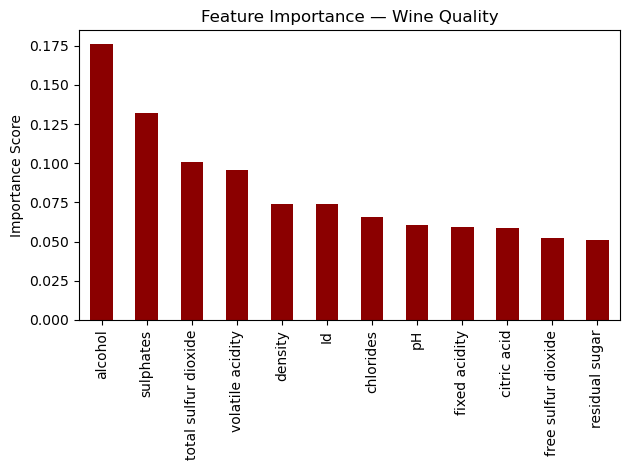

alcohol                 0.176020
sulphates               0.132226
total sulfur dioxide    0.101001
volatile acidity        0.095830
density                 0.073835
Id                      0.073781
chlorides               0.065930
pH                      0.060795
fixed acidity           0.059409
citric acid             0.058387
free sulfur dioxide     0.052094
residual sugar          0.050693
dtype: float64


In [18]:
importance.sort_values(ascending=False).plot(kind='bar', color='darkred')
plt.title("Feature Importance — Wine Quality")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False))

In [19]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Train Accuracy : {train_acc:.2f}")
print(f"Test Accuracy  : {test_acc:.2f}")
print(f"Gap            : {train_acc - test_acc:.2f}")

print()

# Best n_estimators
for n in [10, 50, 100, 200, 500]:
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    test_a = accuracy_score(y_test, m.predict(X_test))
    print(f"Trees: {n:4d}  ->  Test Accuracy: {test_a:.4f}")

Train Accuracy : 1.00
Test Accuracy  : 0.81
Gap            : 0.19

Trees:   10  ->  Test Accuracy: 0.7729
Trees:   50  ->  Test Accuracy: 0.8035
Trees:  100  ->  Test Accuracy: 0.8122
Trees:  200  ->  Test Accuracy: 0.8035
Trees:  500  ->  Test Accuracy: 0.8035


In [20]:
# Create a random wine sample
# Features: [fixed acidity, volatile acidity, citric acid, residual sugar, 
#            chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, 
#            sulphates, alcohol]

random_wine = [[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]]

# Predict
result = model.predict(random_wine)
prob   = model.predict_proba(random_wine)

print("Quality Prediction :", "Good Wine" if result[0] == 1 else "Bad Wine")
print("Confidence        :", round(prob[0][result[0]] * 100, 2), "%")

C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 11 features, but RandomForestClassifier is expecting 12 features as input.

In [21]:
print(X.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


In [22]:
X = df.drop(['quality_binary', 'Id'], axis=1)  # drop both
y = df['quality_binary']



In [23]:
# Create a random wine sample
# Features: [fixed acidity, volatile acidity, citric acid, residual sugar, 
#            chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, 
#            sulphates, alcohol]

random_wine = [[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]]

# Predict
result = model.predict(random_wine)
prob   = model.predict_proba(random_wine)

print("Quality Prediction :", "Good Wine" if result[0] == 1 else "Bad Wine")
print("Confidence        :", round(prob[0][result[0]] * 100, 2), "%")

C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 11 features, but RandomForestClassifier is expecting 12 features as input.

In [24]:
# Get the exact order of features
print("Feature order:")
print(X.columns.tolist())

# Create input as a LIST in EXACT same order
# Order: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, 
#        free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, Id
random_wine = [[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4, 1]]

# Predict
result = model.predict(random_wine)
prob   = model.predict_proba(random_wine)

print("Quality:", "Good Wine" if result[0] == 1 else "Bad Wine")
print("Confidence:", round(prob[0][result[0]] * 100, 2), "%")

Feature order:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Quality: Bad Wine
Confidence: 98.0 %


C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [25]:
wine2 = [[8.5, 0.3, 0.4, 2.1, 0.065, 15.0, 45.0, 0.9965, 3.38, 0.75, 12.8, 2]]

result = model.predict(wine2)
prob   = model.predict_proba(wine2)

print("Wine 2 Quality:", "Good Wine ✅" if result[0] == 1 else "Bad Wine ❌")
print("Confidence:", round(prob[0][result[0]] * 100, 2), "%")

Wine 2 Quality: Good Wine ✅
Confidence: 92.0 %


C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [26]:
wine3 = [[5.2, 1.2, 0.1, 0.8, 0.12, 5.0, 20.0, 0.9950, 3.85, 0.3, 8.5, 3]]

result = model.predict(wine3)
prob   = model.predict_proba(wine3)

print("Wine 3 Quality:", "Good Wine ✅" if result[0] == 1 else "Bad Wine ❌")
print("Confidence:", round(prob[0][result[0]] * 100, 2), "%")

Wine 3 Quality: Bad Wine ❌
Confidence: 77.0 %


C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
